In [8]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "vscode"
df_wof = pd.read_csv("C:\\Users\\nicob\\One Drive Uniandes\\OneDrive - Universidad de los Andes\\Doctorado\\proyecto\\clusterization_project\\data\\datos_resultados_modularizado\\datos_processed_wo_fidelity.csv")
df_woff = df_wof[df_wof['fidelity_v2']>0.5]
df_wf = pd.read_csv("C:\\Users\\nicob\\One Drive Uniandes\\OneDrive - Universidad de los Andes\\Doctorado\\proyecto\\clusterization_project\\data\\datos_resultados_modularizado\\datos_processed_w_fidelity.csv")

In [12]:
df_m = df_wf[['source_id','cluster']].merge(df_wof,on='source_id',suffixes=('_wf','_wof'),how='outer',indicator=True)

In [13]:
df_g = df_m[df_m['_merge']=='both'][['cluster_wof','cluster_wf']].fillna(999).value_counts().reset_index().sort_values(by=['cluster_wof','count'], ascending=[True,False])
df_g = df_g[df_g['count']>20]
df_g

,cluster_wof,cluster_wf,count
2,7.0,27.0,80
0,8.0,38.0,292
1,13.0,14.0,101


In [17]:
diccionario = {}
for i in df_g.index:
    diccionario[df_g.loc[i,'cluster_wof']] = df_g.loc[i,'cluster_wf']

C:\Users\nicob\AppData\Local\Temp\ipykernel_2292\2084303180.py:16: UserWarning:

No data for colormapping provided via 'c'. Parameters 'norm' will be ignored

C:\Users\nicob\AppData\Local\Temp\ipykernel_2292\2084303180.py:22: UserWarning:

No data for colormapping provided via 'c'. Parameters 'norm' will be ignored



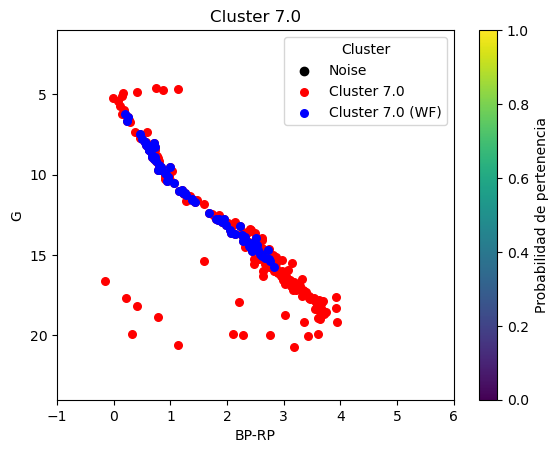

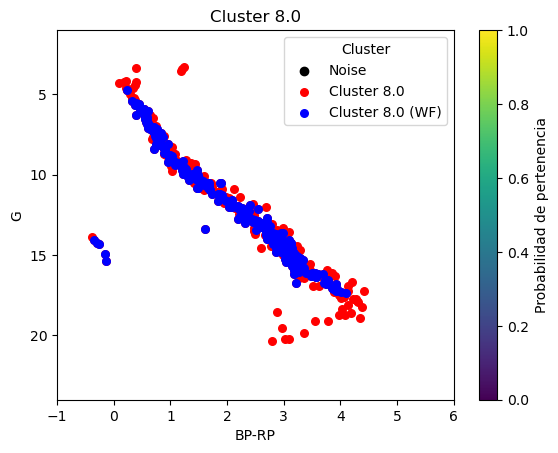

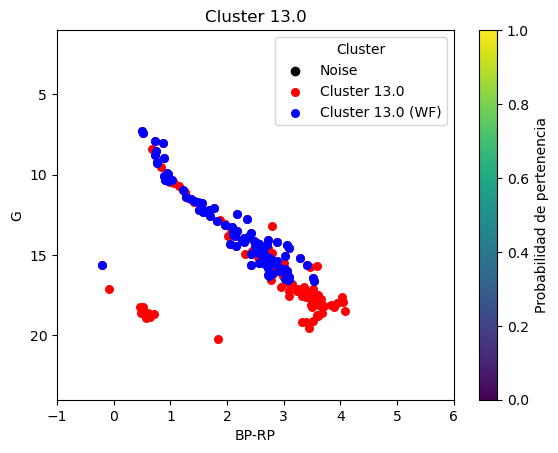

In [20]:
cluster_variable = 'cluster_wof'
for cluster in df_g[cluster_variable].values:
    subset = df_m[df_m[cluster_variable] == cluster]
    subset2 = df_m[df_m['cluster_wf'] == diccionario[cluster]]

    # Dibujar ruido en negro con alfa fijo
    noise = df_m[df_m[cluster_variable] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     color = "r",
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    sc = plt.scatter(subset2['bp_rp'], subset2['phot_g_mean_mag'],
                     color = "b",
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster} (WF)')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

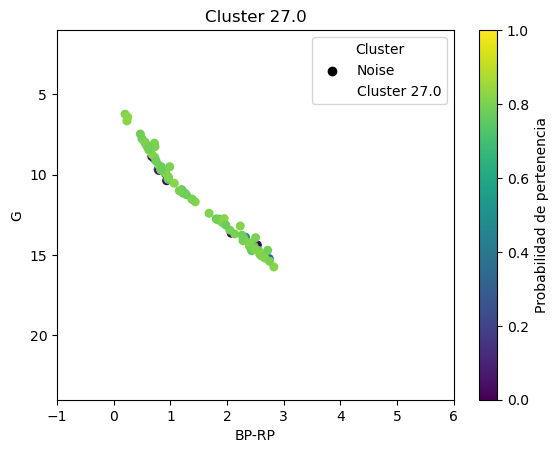

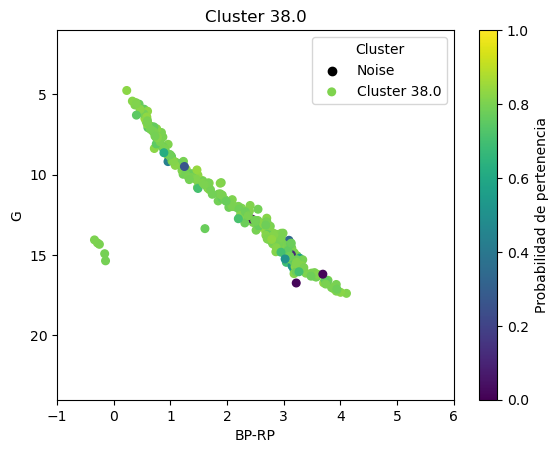

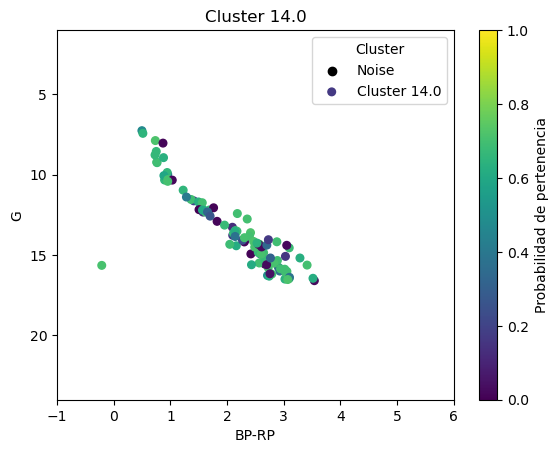

In [15]:
cluster_variable = 'cluster_wf'
for cluster in df_g[cluster_variable].values:
    subset = df_m[df_m[cluster_variable] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = df_m[df_m[cluster_variable] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

In [ ]:
cluster_variable = 'cluster_wf'
for cluster in df_g[cluster_variable].values:
    subset = df_m[df_m[cluster_variable] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = df_m[df_m[cluster_variable] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     color = "r",
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

In [ ]:
cluster_variable = 'cluster_wof'
for cluster in df_g[cluster_variable].values:
    subset = df_m[df_m[cluster_variable] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = df_m[df_m[cluster_variable] < 0]
    plt.hist(noise['parallax'], density=True, label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()